### 1.3.4.4. Taylor and Maclaurin Series

$$
f(x) = \sum_{k=0}^{\infty} \frac{f^{(k)}(a)}{k!}(x - a)^{k}
\quad\xrightarrow{\,a=0\,}\quad
f(x) = \sum_{k=0}^{\infty} \frac{f^{(k)}(0)}{k!}x^{k}\ \ (\text{Maclaurin}).
$$

**Explanation:**

The Taylor series expands a function as a [power series](./03_power_series.ipynb) whose coefficients are built from the function's [derivatives](../02_Single_Variable_Differentiation/06_higher_order_derivatives.ipynb) at the center $a$; the special case $a = 0$ is the Maclaurin series. Truncating after the degree-$n$ term gives the Taylor polynomial $p_n$, the best polynomial match to $f$ at $a$ in value and first $n$ derivatives — the degree-1 piece is precisely the [linear approximation](../02_Single_Variable_Differentiation/10_linear_approximation.ipynb). This local polynomial model is how nonlinear functions are turned into tractable polynomial surrogates for optimization and control.

**Properties:**
- $e^{x} = \sum_{k=0}^{\infty} \tfrac{x^k}{k!}$, $\ \sin x = \sum_{k=0}^{\infty} \tfrac{(-1)^k x^{2k+1}}{(2k+1)!}$, $\ \cos x = \sum_{k=0}^{\infty} \tfrac{(-1)^k x^{2k}}{(2k)!}$.
- The first two terms always reproduce the tangent-line approximation $f(a) + f'(a)(x-a)$.

**Numerical Example:**

Build the Maclaurin polynomials of $f(x) = e^{x}$. Since $f^{(k)}(0) = 1$ for all $k$,

$$
p_1(x) = 1 + x, \quad p_2(x) = 1 + x + \frac{x^2}{2}, \quad p_3(x) = 1 + x + \frac{x^2}{2} + \frac{x^3}{6} .
$$

Estimating $e^{0.5}$ (true value $1.64872\ldots$): $p_1(0.5) = 1.5$, $p_2(0.5) = 1.625$, $p_3(0.5) = 1.6458\overline{3}$ — each added term sharpens the estimate.

In [1]:
import sympy as sp

x = sp.symbols("x")
f = sp.exp(x)
center = 0

taylor_polynomials = [sp.series(f, x, center, order + 1).removeO() for order in range(1, 4)]
estimates = [(degree, polynomial.subs(x, sp.Rational(1, 2)))
             for degree, polynomial in zip(range(1, 4), taylor_polynomials)]

for degree, polynomial in zip(range(1, 4), taylor_polynomials):
    print(f"p_{degree}(x) =", polynomial)
for degree, value in estimates:
    print(f"p_{degree}(0.5) = {value} = {float(value)}")
print("e^0.5 (true) =", sp.N(f.subs(x, sp.Rational(1, 2)), 8))

p_1(x) = x + 1
p_2(x) = x**2/2 + x + 1
p_3(x) = x**3/6 + x**2/2 + x + 1
p_1(0.5) = 3/2 = 1.5
p_2(0.5) = 13/8 = 1.625
p_3(0.5) = 79/48 = 1.6458333333333333
e^0.5 (true) = 1.6487213


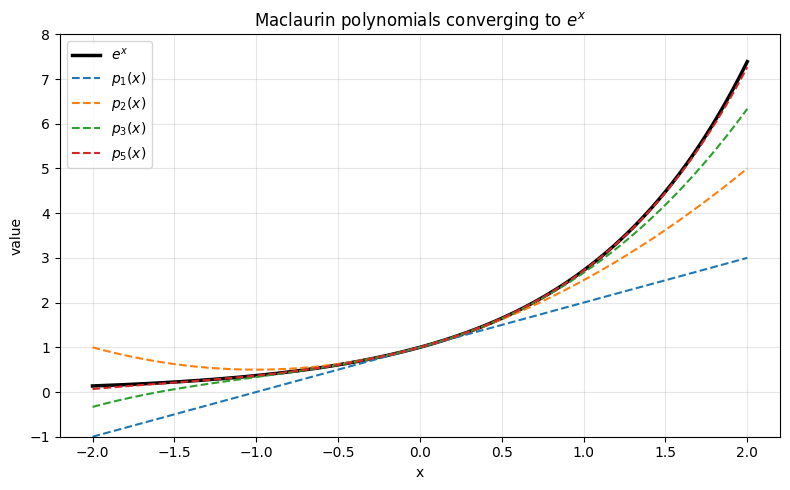

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial

inputs = np.linspace(-2, 2, 400)
exact = np.exp(inputs)

plt.figure(figsize=(8, 5))
plt.plot(inputs, exact, "k", linewidth=2.5, label=r"$e^x$")
for degree in [1, 2, 3, 5]:
    polynomial = sum(inputs**power / factorial(power) for power in range(degree + 1))
    plt.plot(inputs, polynomial, "--", label=f"$p_{{{degree}}}(x)$")
plt.ylim(-1, 8)
plt.xlabel("x"); plt.ylabel("value")
plt.title("Maclaurin polynomials converging to $e^x$")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

**References:**

[📘 Strang, G. (2016). *Calculus Volume 2*. OpenStax.](https://openstax.org/details/books/calculus-volume-2)

---

[⬅️ Previous: Power Series](./03_power_series.ipynb) | [Next: Taylor's Theorem with Remainder ➡️](./05_taylors_theorem_with_remainder.ipynb)